# Created using following the tutorial https://www.youtube.com/watch?v=G_yqv0Vj3ug

In [1]:
# %pip install hyperspy
#%pip install hyperspy_gui_ipywidgets ipywidgets

%matplotlib widget
import hyperspy.api as hs
import tkinter as tk
from tkinter import filedialog

In [31]:
# Create a function to select a file
def load_file():
    root = tk.Tk()
    root.withdraw()  # Hide the root window

    file_path = filedialog.askopenfilename(
        title="Select a .hspy file",
        filetypes=[("All Files", "*.*"),("Hyperspy Files", "*.hspy") ]
    )

    if file_path:  # If a file is selected
        print("Selected file:", file_path)
        data = hs.load(file_path)
        print(data)
        return data  # Return loaded data

    return None  # If no file is selected

# Load the selected file
data = load_file()

Selected file: /workspaces/SAXS_WAXS/TEM_analysis files/1S__0003_Single_Spectrum_Range2.hspy
WARNING | Hyperspy | `signal_type='EELS'` not understood. See `hs.print_known_signal_types()` for a list of installed signal types or https://github.com/hyperspy/hyperspy-extensions-list for the list of all hyperspy extensions providing signals. (hyperspy.io:893)
<Signal1D, title: , dimensions: (50, 50|1638)>


In [32]:
data.plot() # Plot the raw data 

WARNING | Hyperspy | `signal_type='EELS'` not understood. See `hs.print_known_signal_types()` for a list of installed signal types or https://github.com/hyperspy/hyperspy-extensions-list for the list of all hyperspy extensions providing signals. (hyperspy.io:893)
WARNING | Hyperspy | `signal_type='EELS'` not understood. See `hs.print_known_signal_types()` for a list of installed signal types or https://github.com/hyperspy/hyperspy-extensions-list for the list of all hyperspy extensions providing signals. (hyperspy.io:893)


/home/vscode/.local/lib/python3.11/site-packages/hyperspy/drawing/utils.py:161: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(**kwargs)


# Apply a manual shift for correct alignment 

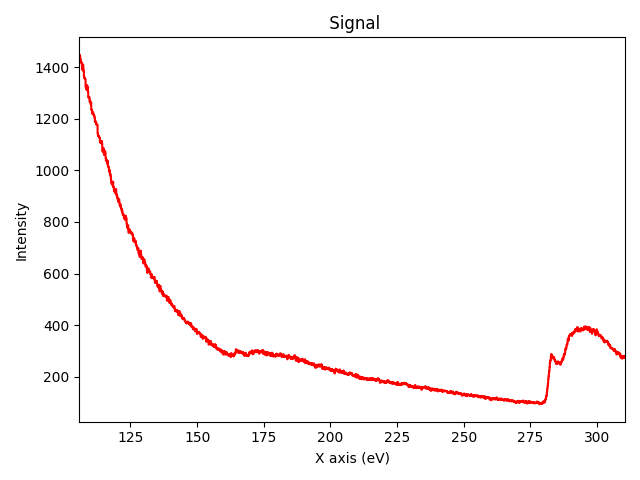

In [27]:
def align_data(input_file, shift):
    data_corrected = input_file.deepcopy()
    import numpy as np

    # Shift value wrapped in a NumPy array
    shift_array = np.array([shift])

    # Apply the shift
    # Apply shift and expand the data to retain all information
    data_corrected.shift1D(shift_array, interpolation_method = 'linear', expand= False)
    data_corrected.plot() # Plot the shifted data
    return data_corrected

data_corrected = align_data(data, 0) # Shift the data 

In [ ]:
data_manual_calibration = data.deepcopy()
data_manual_calibration.calibrate()
data_manual_calibration.plot()

# Smooth the data 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


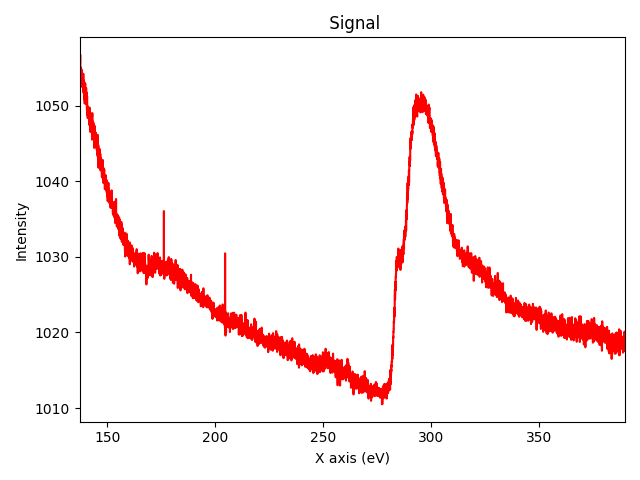

In [5]:
# Ensure the required package and dependencies are installed
%pip install pyface traits

# Plot and smooth the data
data_corrected.plot()
data_corrected.smooth_savitzky_golay(2, 20)   #(ploynomial order, Window size)

# Data cropping 

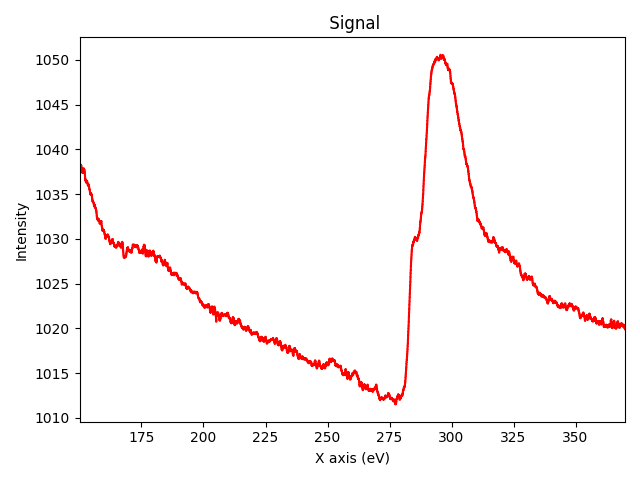

In [7]:
#cropped_data = data_corrected.isig[135.0:350.0]
cropped_data = data_corrected.isig[150.0:370.0]
cropped_data.plot()

# Save the data as a txt file

In [8]:
import numpy as np
import os

# Extract data from the HyperSpy Signal1D object
energy_axis = cropped_data.axes_manager[0].axis.copy()  # Energy loss values
core_loss_data = cropped_data.data.copy()  # Intensity values

# Stack the data into two columns (Energy Loss, Intensity)
data_to_save = np.column_stack((energy_axis, core_loss_data))

# Define the filename
filename = "low_loss_spectrum.txt"

# Save the file in the current working directory
filepath = os.path.join(os.getcwd(), filename)
np.savetxt(filepath, data_to_save, delimiter="\t", header="Energy Loss (eV)\tIntensity", comments='')

# Print the saved file path
print(f"File saved at: {filepath}")


File saved at: /workspaces/SAXS_WAXS/TEM_analysis files/low_loss_spectrum.txt


# Remove background 

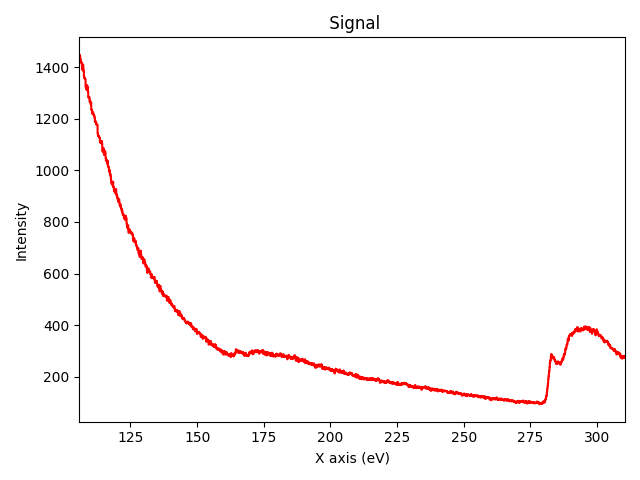

WARNING | Hyperspy | Numexpr is not installed, falling back to numpy, which is slower to calculate model. (hyperspy._components.expression:186)
WARNING | Hyperspy | Numexpr is not installed, falling back to numpy, which is slower to calculate model. (hyperspy._components.expression:186)


/home/vscode/.local/lib/python3.11/site-packages/jupyter_client/session.py:727: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


In [28]:

background_subtracted = data_corrected.deepcopy()
background_subtracted.plot()
background_subtracted.remove_background()


# Save all the data

In [29]:
import numpy as np
import os

# 1) Keep original
orig = data_corrected.deepcopy()

# 2) Background subtraction (works whether method is in-place or returns a new signal)
work = data_corrected.deepcopy()
res = work.remove_background(
    signal_range=(138, 161),
    background_type="Power law",
    fast=False
)
bg_sub = res if hasattr(res, "data") else work  # handle both API behaviors

# 3) Build arrays
E = orig.axes_manager[0].axis.copy()
I_orig = orig.data.copy()
I_sub = bg_sub.data.copy()
I_bg = I_orig - I_sub

# 4) Sanity check
max_bg = np.max(np.abs(I_bg))
print("Max |background|:", max_bg)

# 5) Save all columns
out = np.column_stack([E, I_orig, I_bg, I_sub])
header = "Energy Loss (eV)\tOriginal\tBackground_fit\tBackground_subtracted"
filepath = os.path.join(os.getcwd(), "background_process_all_columns.txt")
np.savetxt(filepath, out, delimiter="\t", header=header, comments="")
print(f"Saved: {filepath}")


WARNING | Hyperspy | Numexpr is not installed, falling back to numpy, which is slower to calculate model. (hyperspy._components.expression:186)


Max |background|: 1400.2159206171636
Saved: /workspaces/SAXS_WAXS/TEM_analysis files/background_process_all_columns.txt


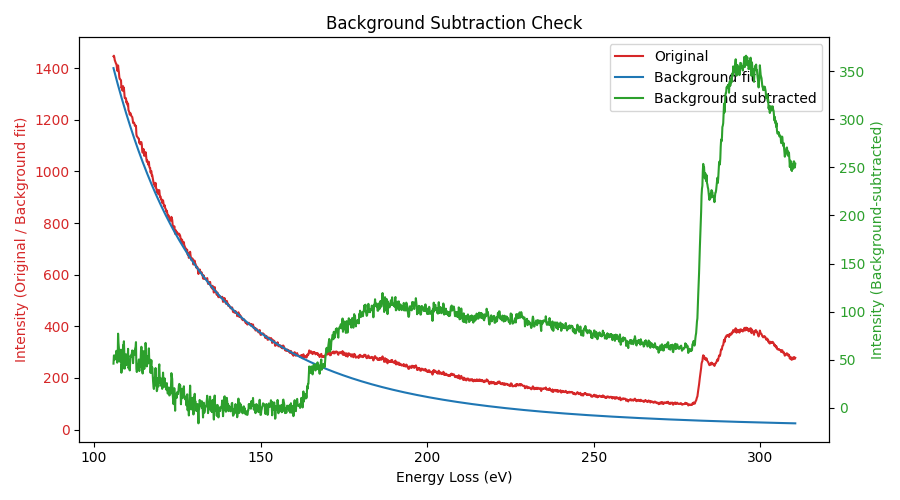

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import os

filepath = os.path.join(os.getcwd(), "background_process_all_columns.txt")

# Load (skip header row)
data = np.loadtxt(filepath, delimiter="\t", skiprows=1)

E = data[:, 0]
I_orig = data[:, 1]
I_bg = data[:, 2]
I_sub = data[:, 3]

fig, ax1 = plt.subplots(figsize=(9, 5))

# Left y-axis: original + background fit
l1, = ax1.plot(E, I_orig, color="tab:red", label="Original")
l2, = ax1.plot(E, I_bg, color="tab:blue", label="Background fit")
ax1.set_xlabel("Energy Loss (eV)")
ax1.set_ylabel("Intensity (Original / Background fit)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

# Right y-axis: background-subtracted
ax2 = ax1.twinx()
l3, = ax2.plot(E, I_sub, color="tab:green", label="Background subtracted")
ax2.set_ylabel("Intensity (Background-subtracted)", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")

# Combined legend
lines = [l1, l2, l3]
labels = [ln.get_label() for ln in lines]
ax1.legend(lines, labels, loc="best")

plt.title("Background Subtraction Check")
plt.tight_layout()
plt.show()



# Correction for multiple ineleastic scattering arising from thick samples 

In [ ]:
core_loss_spectra = load_file()
core_loss_spectra.set_signal_type("EELS")
low_loss_spectra = load_file()
low_loss_spectra.set_signal_type("EELS")

core_loss_spectra.plot()

In [ ]:
shift_in_eV = 2.0
aligned_core_loss_spectra = align_data(core_loss_spectra, shift_in_eV)
aligned_low_loss_spectra = align_data(low_loss_spectra, shift_in_eV)

In [ ]:
# Convert Signal1D to EELSSpectrum
aligned_core_loss_spectra.set_signal_type("EELS")
aligned_low_loss_spectra.set_signal_type("EELS")

# Now perform Richardson-Lucy deconvolution
corrected_core_loss = aligned_core_loss_spectra.richardson_lucy_deconvolution(
    psf=aligned_low_loss_spectra,
    iterations=15,
    show_progressbar=True
)

# Plot results
aligned_core_loss_spectra.plot(label="Raw Core-Loss", color="red")
corrected_core_loss.plot(label="RL-Deconvolved", color="blue")